In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Basic transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

# Reduce dataset for faster training
trainset = torch.utils.data.Subset(trainset, range(10000))
testset = torch.utils.data.Subset(testset, range(2000))

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print("Train batches:", len(trainloader))
print("Test batches:", len(testloader))

Using device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Train batches: 157
Test batches: 32


In [2]:
import random, numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
import torch
import torch.nn as nn
import math

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()

        self.in_features = in_features
        self.out_features = out_features

        # Weight and bias
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Gate scores
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        # Standard initialization
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.constant_(self.gate_scores, -2.0)  # start gates ~0.5 after sigmoid

        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / math.sqrt(fan_in)
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        # Convert gate_scores
        gates = torch.sigmoid(self.gate_scores)

        # Apply pruning
        pruned_weights = self.weight * gates

        # Manual linear operation
        output = x @ pruned_weights.t() + self.bias

        return output

In [4]:
layer = PrunableLinear(10, 5)

x = torch.randn(4, 10)  # batch of 4
output = layer(x)

print("Output shape:", output.shape)

# gradients
loss = output.mean()
loss.backward()

print("Weight grad exists:", layer.weight.grad is not None)
print("Gate grad exists:", layer.gate_scores.grad is not None)

Output shape: torch.Size([4, 5])
Weight grad exists: True
Gate grad exists: True


In [5]:
def get_gates(self):
    return torch.sigmoid(self.gate_scores)

In [6]:
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(3 * 32 * 32, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [7]:
model = PrunableNet().to(device)

x = torch.randn(8, 3, 32, 32).to(device)
output = model(x)

print("Output shape:", output.shape)

Output shape: torch.Size([8, 10])


In [8]:
def compute_sparsity_loss(model):
    sparsity_loss = 0.0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            sparsity_loss += gates.mean()

    return sparsity_loss

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
def train_one_epoch(model, trainloader, optimizer, lambda_sparse):
    model.train()

    total_loss = 0
    total_ce = 0
    total_sparse = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Classification loss
        ce_loss = criterion(outputs, labels)

        # Sparsity loss (L1 on gates)
        sparsity_loss = compute_sparsity_loss(model)

        # Total loss
        loss = ce_loss + lambda_sparse * sparsity_loss

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Accumulate losses
        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_sparse += sparsity_loss.item()

    # Average losses
    avg_loss = total_loss / len(trainloader)
    avg_ce = total_ce / len(trainloader)
    avg_sparse = total_sparse / len(trainloader)

    print(f"Loss: {avg_loss:.4f} | CE: {avg_ce:.4f} | Sparse: {avg_sparse:.4f}")

    return avg_loss

In [11]:
lambda_sparse = 0.001

loss = train_one_epoch(model, trainloader, optimizer, lambda_sparse)

print("Training loss:", loss)

Loss: 2.0640 | CE: 2.0636 | Sparse: 0.3585
Training loss: 2.064000312689763


In [12]:
def evaluate_accuracy(model, testloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [13]:
def compute_sparsity(model, threshold=0.1):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [14]:
def run_experiment(lambda_sparse):
    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    print(f"\nRunning for lambda = {lambda_sparse}")

    for epoch in range(15):
        print(f"Epoch {epoch+1}")
        loss = train_one_epoch(model, trainloader, optimizer, lambda_sparse)
        print(f"Epoch {epoch+1}, Loss: {loss:.2f}")

    acc = evaluate_accuracy(model, testloader)
    sparsity = compute_sparsity(model)

    print(f"Test Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")

    return acc, sparsity, model

In [15]:
results = {}
models = {}

lambdas = [0.01, 0.1, 0.5]

for lam in lambdas:
    acc, sparsity, model = run_experiment(lam)
    results[lam] = (acc, sparsity)
    models[lam] = model


Running for lambda = 0.01
Epoch 1
Loss: 2.0701 | CE: 2.0666 | Sparse: 0.3566
Epoch 1, Loss: 2.07
Epoch 2
Loss: 1.8378 | CE: 1.8342 | Sparse: 0.3553
Epoch 2, Loss: 1.84
Epoch 3
Loss: 1.7399 | CE: 1.7363 | Sparse: 0.3535
Epoch 3, Loss: 1.74
Epoch 4
Loss: 1.6640 | CE: 1.6605 | Sparse: 0.3520
Epoch 4, Loss: 1.66
Epoch 5
Loss: 1.6013 | CE: 1.5978 | Sparse: 0.3507
Epoch 5, Loss: 1.60
Epoch 6
Loss: 1.5442 | CE: 1.5407 | Sparse: 0.3495
Epoch 6, Loss: 1.54
Epoch 7
Loss: 1.4912 | CE: 1.4878 | Sparse: 0.3485
Epoch 7, Loss: 1.49
Epoch 8
Loss: 1.4408 | CE: 1.4374 | Sparse: 0.3478
Epoch 8, Loss: 1.44
Epoch 9
Loss: 1.3930 | CE: 1.3895 | Sparse: 0.3471
Epoch 9, Loss: 1.39
Epoch 10
Loss: 1.3506 | CE: 1.3472 | Sparse: 0.3466
Epoch 10, Loss: 1.35
Epoch 11
Loss: 1.2964 | CE: 1.2929 | Sparse: 0.3462
Epoch 11, Loss: 1.30
Epoch 12
Loss: 1.2483 | CE: 1.2448 | Sparse: 0.3459
Epoch 12, Loss: 1.25
Epoch 13
Loss: 1.2015 | CE: 1.1980 | Sparse: 0.3457
Epoch 13, Loss: 1.20
Epoch 14
Loss: 1.1452 | CE: 1.1417 | Spars

In [16]:
for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores)
        print("Mean gate:", gates.mean().item())

Mean gate: 0.10850444436073303
Mean gate: 0.08602219820022583
Mean gate: 0.08819068968296051


In [17]:
import matplotlib.pyplot as plt

def plot_gate_distribution(model, title="Gate Distribution"):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title(title)
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

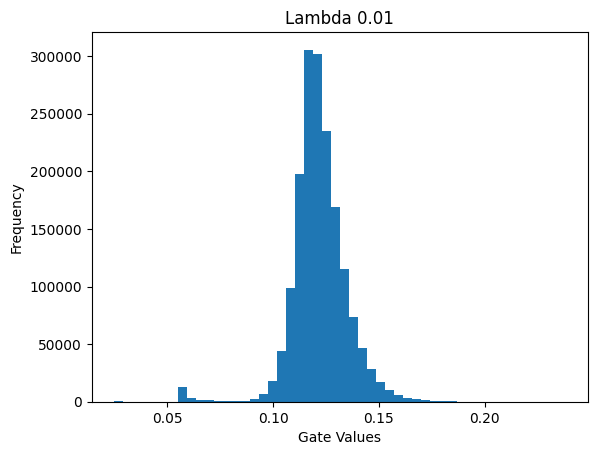

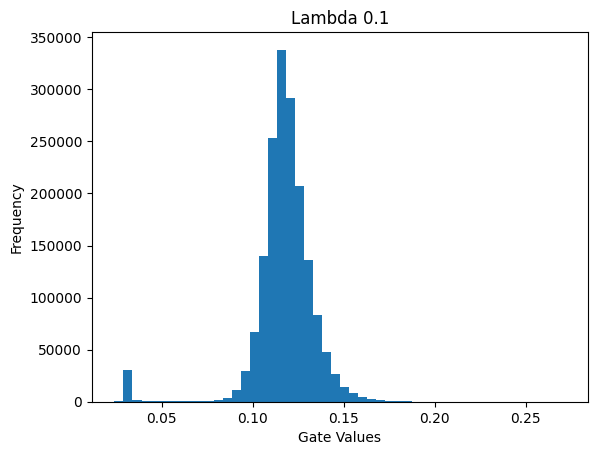

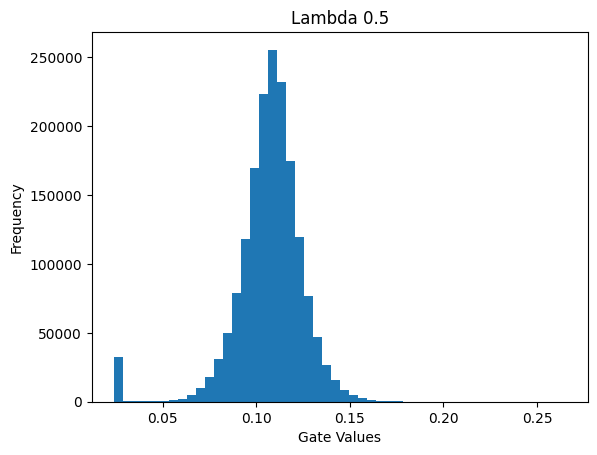

In [18]:
for lam, model in models.items():
    plot_gate_distribution(model, f"Lambda {lam}")

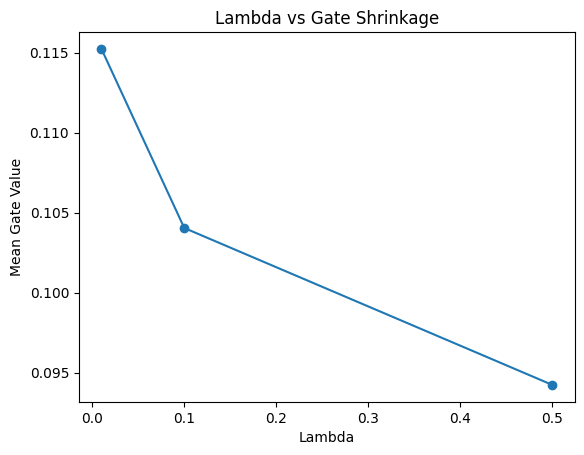

In [19]:
mean_gates = []

for lam in lambdas:
    model = models[lam]
    vals = []
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            vals.append(torch.sigmoid(m.gate_scores).mean().item())
    mean_gates.append(sum(vals)/len(vals))

plt.figure()
plt.plot(lambdas, mean_gates, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Mean Gate Value")
plt.title("Lambda vs Gate Shrinkage")
plt.show()

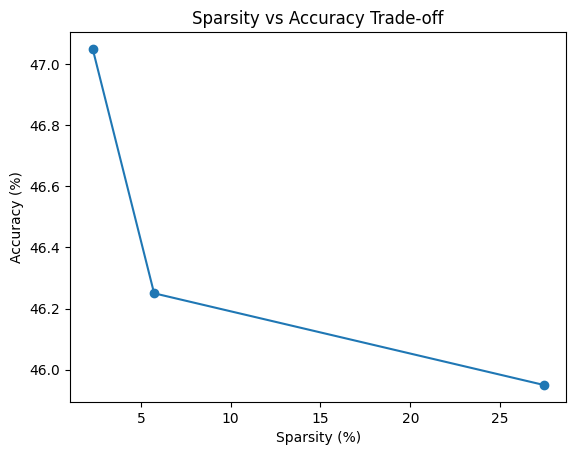

In [20]:
import matplotlib.pyplot as plt

lams = list(results.keys())
accuracies = [results[l][0] for l in lams]
sparsities = [results[l][1] for l in lams]

plt.figure()
plt.plot(sparsities, accuracies, marker='o')
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Sparsity vs Accuracy Trade-off")
plt.show()